# Automatización de preprocesamiento medianto pipelines

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [25]:
# Cargamos los datos
df_d = pd.read_csv("./diabetes.csv")
df_d = df_d.drop(columns=["Unnamed: 0"])

# Dividimos los datos en conjunto de entrenamiento y prueba
train_set, test_set = train_test_split(
    df_d, test_size=0.2, stratify=df_d["Outcome"], random_state=42
)

# Separamos predictores y etiquetas
d_train = train_set.drop("Outcome", axis=1)
d_labels = train_set["Outcome"].copy()

In [26]:
from sklearn.preprocessing import FunctionTransformer
#creamos un transformador
log_transformer = FunctionTransformer(
    np.log1p,
    inverse_func=np.expm1, #calcula la inversa (que es lo que queremos )
    feature_names_out="one-to-one" #el nombre de las caracteristicas 1 a 1
)
log_pop = log_transformer.fit_transform(d_train[["Insulin"]]) 

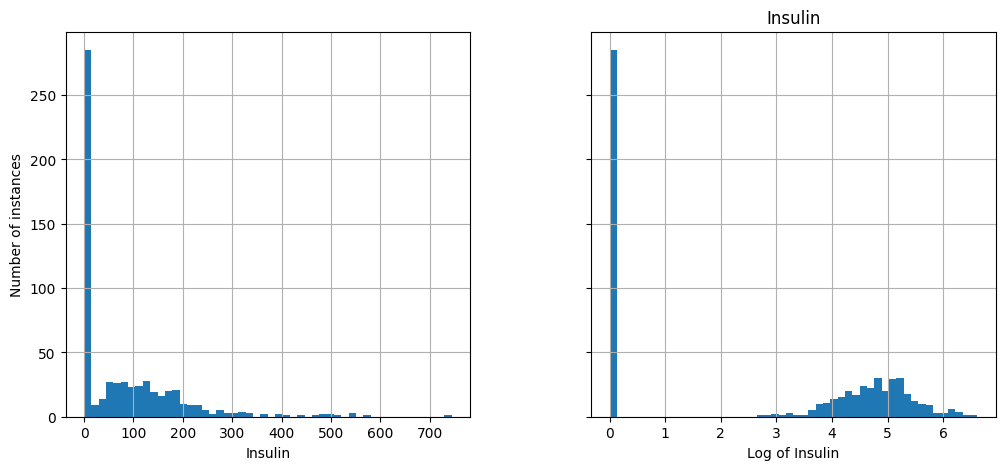

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

d_train["Insulin"].hist(ax=axs[0], bins=50)
log_pop.hist(ax=axs[1], bins=50)

axs[0].set_xlabel("Insulin")
axs[1].set_xlabel("Log of Insulin")
axs[0].set_ylabel("Number of instances")

plt.show()

# Diseño del pipleline de preprocesamiento

In [32]:
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import make_pipeline

num_attribs = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
               "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
cat_attribs = ["Outcome"]

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])
#creamos pipeline para columnas categoricas
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # usamos la categoria mas frencuente para imputar los valores
    OneHotEncoder(handle_unknown="ignore") 
    )

preprocessing = ColumnTransformer([ #usamos columntransformer para aplicar atributos numericos el pipeline numerico y a los categoricos el pipeline categoricos
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [33]:
d_num = d_train

d_num_prepared = num_pipeline.fit_transform(d_num) 
d_num_prepared[:2].round(2)

array([[-0.85, -0.98, -0.42, -0.59, -0.34, -0.62,  0.31, -0.79],
       [ 0.36,  0.16,  0.46,  0.37, -0.53, -0.31, -0.12,  0.56]])

In [34]:
num_pipeline.get_feature_names_out() 

array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object)

In [35]:
null_rows_idx = d_train.isnull().any(axis=1)

df_d_num_prepared = pd.DataFrame(
    d_num_prepared, columns=num_pipeline.get_feature_names_out(),index=d_num.index)
df_d_num_prepared[null_rows_idx] #el que transformamos 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
33,0.658558,-0.916710,1.234806,0.116132,-0.735294,-1.565018,-0.876973,-0.453869
9,1.262524,0.129734,1.454917,0.116132,-0.335153,0.035377,-0.743652,1.745087
26,0.960541,0.827363,0.354364,0.116132,-0.735294,0.951732,-0.667902,0.814759
21,1.262524,-0.694737,0.794585,0.116132,-0.735294,0.435476,-0.270969,1.406786
22,0.960541,2.381173,1.124751,0.116132,-0.735294,1.003358,-0.080078,0.645609
10,0.054593,-0.345922,1.234806,0.116132,-0.335153,0.719417,-0.867883,-0.284718
12,1.866489,0.573680,0.574474,0.116132,-0.335153,-0.635756,2.919638,1.998812
7,1.866489,-0.187370,0.134253,0.116132,-0.335153,0.422569,-1.040594,-0.369293
15,0.960541,-0.663027,-3.827738,0.116132,-0.735294,-0.261470,0.019912,-0.115568
29,0.356576,-0.123950,1.234806,0.116132,-0.735294,0.267692,-0.425500,0.391883


Aplicamos transformer

In [36]:
df_d_prepared = preprocessing.fit_transform(d_train) #la transformacion la aplico sobre todo los datos de entrenamiento

ValueError: Some column names are not columns of the dataframe: {'Outcome'}

In [ ]:
preprocessing.get_feature_names_out()

In [ ]:
df_d_prepared = pd.DataFrame(
    df_d_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=d_train.index)

df_d_prepared.head()

# Implementación del pipeline


# Aplicación del pipeline

#  Verificación del resultado